# Consumer Complaint Analysis — Modeling

## Objective

The objective of this notebook is to build and evaluate machine learning models that predict the company's response to a consumer complaint.

The prediction target is:

`company_response_to_consumer`

The model will use information available at or shortly after complaint submission, without using features that represent the company's later response or outcome.

The modeling process will focus on:

- Establishing a baseline
- Training candidate classification models
- Evaluating performance using appropriate metrics
- Paying particular attention to class imbalance
- Comparing model performance
- Understanding which features contribute to prediction
- Selecting a final model based on both performance and practical usefulness

In [3]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\ThisPC\Desktop\Consumer Complain Project\notebooks
['01_Auditing_Data.ipynb', '02_Data_Cleaning.ipynb', '03_EDA.ipynb', '04_EDA_company_consumer_response.ipynb', '05_Feature_Audit.ipynb', '06_Feature_Engineering.ipynb', '07_Modeling.ipynb', '08_Model_Evaluation.ipynb', '09_Prediction_Pipeline.ipynb', '10_building_ui.ipynb', 'Untitled0.ipynb']


In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
PROJECT_PATH = "/content/drive/MyDrive/Consumer Complain Project"

PROCESSED_PATH = f"{PROJECT_PATH}/data/processed"

## 1. Load Model-Ready Data

Loaded directly from the parquet files produced by `06_Feature_Engineering.ipynb` — no re-processing here.

In [4]:
X_train = pd.read_parquet(f"{PROCESSED_PATH}/X_train.parquet")
X_test = pd.read_parquet(f"{PROCESSED_PATH}/X_test.parquet")

y_train = pd.read_parquet(f"{PROCESSED_PATH}/y_train.parquet")
y_test = pd.read_parquet(f"{PROCESSED_PATH}/y_test.parquet")

In [5]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTarget column:")
print(y_train.columns.tolist())

print("\nTraining target distribution:")
print(y_train.iloc[:, 0].value_counts())

X_train shape: (51870, 262)
X_test shape: (12968, 262)
y_train shape: (51870, 1)
y_test shape: (12968, 1)

Target column:
['company_response_to_consumer']

Training target distribution:
company_response_to_consumer
Closed with explanation            40679
Closed with non-monetary relief     9517
Closed with monetary relief         1261
Untimely response                    413
Name: count, dtype: int64


In [6]:
print("Feature columns match:", X_train.columns.equals(X_test.columns))
print("Number of training features:", X_train.shape[1])
print("Number of test features:", X_test.shape[1])

Feature columns match: True
Number of training features: 262
Number of test features: 262


In [7]:
print("Missing values in X_train:", X_train.isna().sum().sum())
print("Missing values in X_test:", X_test.isna().sum().sum())

print("Infinite values in X_train:", np.isinf(X_train.to_numpy()).sum())
print("Infinite values in X_test:", np.isinf(X_test.to_numpy()).sum())

Missing values in X_train: 0
Missing values in X_test: 0
Infinite values in X_train: 0
Infinite values in X_test: 0


In [8]:
print("Missing values in y_train:", y_train.iloc[:, 0].isna().sum())
print("Missing values in y_test:", y_test.iloc[:, 0].isna().sum())

print("\nNumber of classes in y_train:", y_train.iloc[:, 0].nunique())
print("Number of classes in y_test:", y_test.iloc[:, 0].nunique())

print("\nTraining classes:")
print(sorted(y_train.iloc[:, 0].unique()))

print("\nTest classes:")
print(sorted(y_test.iloc[:, 0].unique()))

Missing values in y_train: 0
Missing values in y_test: 0

Number of classes in y_train: 4
Number of classes in y_test: 4

Training classes:
['Closed with explanation', 'Closed with monetary relief', 'Closed with non-monetary relief', 'Untimely response']

Test classes:
['Closed with explanation', 'Closed with monetary relief', 'Closed with non-monetary relief', 'Untimely response']


### Key Finding — Data Integrity

51,870 training rows / 12,968 test rows, 262 features, columns match exactly between train and test, zero missing or infinite values, and both splits contain all four target classes. The data is clean and ready to model — no additional preprocessing needed here.

## 2. Baseline

A `DummyClassifier` predicting the majority class every time. This is the number every real model has to beat — and it's a trap metric, since it will show high accuracy while being completely useless.

In [9]:
X_train_model = X_train
X_test_model = X_test

y_train_model = y_train.iloc[:, 0]
y_test_model = y_test.iloc[:, 0]

baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train_model, y_train_model)

baseline_predictions = baseline_model.predict(X_test_model)

In [10]:
baseline_accuracy = accuracy_score(y_test_model, baseline_predictions)
baseline_balanced_accuracy = balanced_accuracy_score(y_test_model, baseline_predictions)
baseline_macro_f1 = f1_score(y_test_model, baseline_predictions, average="macro")

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print(f"Baseline Balanced Accuracy: {baseline_balanced_accuracy:.4f}")
print(f"Baseline Macro F1: {baseline_macro_f1:.4f}")

Baseline Accuracy: 0.7842
Baseline Balanced Accuracy: 0.2500
Baseline Macro F1: 0.2198


In [11]:
print("Baseline prediction distribution:")
print(pd.Series(baseline_predictions).value_counts())

print("\nActual test distribution:")
print(y_test_model.value_counts())

Baseline prediction distribution:
Closed with explanation    12968
Name: count, dtype: int64

Actual test distribution:
company_response_to_consumer
Closed with explanation            10170
Closed with non-monetary relief     2380
Closed with monetary relief          315
Untimely response                    103
Name: count, dtype: int64


### Key Finding — Baseline

78.42% accuracy — deceptively high, and entirely explained by the fact that "Closed with explanation" makes up 78.42% of the test set and the baseline predicts it every single time. Balanced accuracy (0.25 = 1/4 classes) and macro-F1 (0.22) show the real picture: this model has zero ability to distinguish classes. Any real model needs to beat macro-F1 of 0.22, not accuracy of 78%.

## 3. Logistic Regression (Class-Weighted, Scaled)

Logistic Regression benefits from feature scaling, unlike the tree-based models used later — so features are standardized here specifically for this model. `class_weight="balanced"` reweights the loss function so minority classes aren't ignored in training.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_model)
X_test_scaled = scaler.transform(X_test_model)

In [14]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

In [15]:
logistic_model.fit(X_train_scaled, y_train_model)

logistic_predictions = logistic_model.predict(X_test_scaled)

In [16]:
logistic_accuracy = accuracy_score(y_test_model, logistic_predictions)
logistic_balanced_accuracy = balanced_accuracy_score(y_test_model, logistic_predictions)
logistic_macro_f1 = f1_score(y_test_model, logistic_predictions, average="macro")

print(f"Logistic Regression Accuracy: {logistic_accuracy:.4f}")
print(f"Logistic Regression Balanced Accuracy: {logistic_balanced_accuracy:.4f}")
print(f"Logistic Regression Macro F1: {logistic_macro_f1:.4f}")

Logistic Regression Accuracy: 0.4236
Logistic Regression Balanced Accuracy: 0.6834
Logistic Regression Macro F1: 0.3194


In [17]:
print("Logistic Regression Classification Report:\n")

print(
    classification_report(
        y_test_model,
        logistic_predictions,
        zero_division=0
    )
)

Logistic Regression Classification Report:

                                 precision    recall  f1-score   support

        Closed with explanation       0.85      0.35      0.50     10170
    Closed with monetary relief       0.16      0.92      0.27       315
Closed with non-monetary relief       0.27      0.65      0.38      2380
              Untimely response       0.07      0.81      0.13       103

                       accuracy                           0.42     12968
                      macro avg       0.34      0.68      0.32     12968
                   weighted avg       0.72      0.42      0.47     12968



In [18]:
logistic_cm = confusion_matrix(
    y_test_model,
    logistic_predictions,
    labels=logistic_model.classes_
)

logistic_cm_df = pd.DataFrame(
    logistic_cm,
    index=logistic_model.classes_,
    columns=logistic_model.classes_
)

print("Logistic Regression Confusion Matrix:\n")
display(logistic_cm_df)

Logistic Regression Confusion Matrix:



,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,Untimely response
Closed with explanation,3564,1439,4197,970
Closed with monetary relief,11,291,2,11
Closed with non-monetary relief,603,111,1555,111
Untimely response,10,8,2,83


In [19]:
model_results = pd.DataFrame({
    "Model": ["Dummy Baseline", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test_model, baseline_predictions),
        logistic_accuracy
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test_model, baseline_predictions),
        logistic_balanced_accuracy
    ],
    "Macro F1": [
        f1_score(y_test_model, baseline_predictions, average="macro"),
        logistic_macro_f1
    ]
})

display(model_results)

,Model,Accuracy,Balanced Accuracy,Macro F1
0,Dummy Baseline,0.784238,0.25000,0.219768
1,Logistic Regression,0.423581,0.68336,0.319384


### Key Finding — Logistic Regression

Class weighting works as intended for recall — 81-92% recall on all three minority classes, a massive jump from the baseline's 0%. But precision collapses (7-16% for Monetary relief and Untimely response), meaning the model over-flags almost everything as a minority class to catch them all. Overall accuracy drops to 42% as a direct trade-off. Macro-F1 of 0.319 beats the baseline (0.22) but is the weakest of the three real models — worth keeping as a interpretable reference point, not a leading candidate.

## 4. Random Forest (Class-Weighted)

Tree-based, no scaling needed. Also uses `class_weight="balanced"`.

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [22]:
random_forest_model.fit(
    X_train_model,
    y_train_model
)

random_forest_predictions = random_forest_model.predict(
    X_test_model
)

In [23]:
random_forest_accuracy = accuracy_score(
    y_test_model,
    random_forest_predictions
)

random_forest_balanced_accuracy = balanced_accuracy_score(
    y_test_model,
    random_forest_predictions
)

random_forest_macro_f1 = f1_score(
    y_test_model,
    random_forest_predictions,
    average="macro"
)

print(f"Random Forest Accuracy: {random_forest_accuracy:.4f}")
print(f"Random Forest Balanced Accuracy: {random_forest_balanced_accuracy:.4f}")
print(f"Random Forest Macro F1: {random_forest_macro_f1:.4f}")

Random Forest Accuracy: 0.8225
Random Forest Balanced Accuracy: 0.4249
Random Forest Macro F1: 0.4805


In [24]:
print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test_model,
        random_forest_predictions,
        zero_division=0
    )
)

Random Forest Classification Report:

                                 precision    recall  f1-score   support

        Closed with explanation       0.85      0.94      0.89     10170
    Closed with monetary relief       0.47      0.05      0.10       315
Closed with non-monetary relief       0.65      0.43      0.52      2380
              Untimely response       0.88      0.27      0.41       103

                       accuracy                           0.82     12968
                      macro avg       0.71      0.42      0.48     12968
                   weighted avg       0.80      0.82      0.80     12968



In [25]:
model_results.loc[len(model_results)] = {
    "Model": "Random Forest",
    "Accuracy": random_forest_accuracy,
    "Balanced Accuracy": random_forest_balanced_accuracy,
    "Macro F1": random_forest_macro_f1
}

display(model_results)

,Model,Accuracy,Balanced Accuracy,Macro F1
0,Dummy Baseline,0.784238,0.250000,0.219768
1,Logistic Regression,0.423581,0.683360,0.319384
2,Random Forest,0.822486,0.424931,0.480548


### Key Finding — Random Forest's Class Weighting Underperforms

This is the most important finding in the model comparison. Random Forest shows the highest raw accuracy of the three real models (82%) — but only **5% recall on Closed with monetary relief** and **27% on Untimely response**. Despite `class_weight="balanced"`, it is still effectively defaulting to the majority class for the rarest outcomes. High accuracy here is actively misleading: it comes from correctly predicting the 78% majority class, not from solving the actual problem. This is a case where tree-ensemble class weighting behaves very differently from Logistic Regression's loss-based weighting — it does not guarantee balanced recall. Random Forest is not a candidate for the final model despite its accuracy.

## 5. HistGradientBoosting (Class-Weighted)

Native multi-class gradient boosting, no scaling needed, with the same class-weighting approach as the other two models for a fair comparison.

In [26]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [27]:
gradient_boosting_model = HistGradientBoostingClassifier(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    class_weight="balanced",
    random_state=42
)

In [28]:
gradient_boosting_model.fit(
    X_train_model,
    y_train_model
)

gradient_boosting_predictions = gradient_boosting_model.predict(
    X_test_model
)

In [29]:
gradient_boosting_accuracy = accuracy_score(
    y_test_model,
    gradient_boosting_predictions
)

gradient_boosting_balanced_accuracy = balanced_accuracy_score(
    y_test_model,
    gradient_boosting_predictions
)

gradient_boosting_macro_f1 = f1_score(
    y_test_model,
    gradient_boosting_predictions,
    average="macro"
)

print(f"HistGradientBoosting Accuracy: {gradient_boosting_accuracy:.4f}")
print(f"HistGradientBoosting Balanced Accuracy: {gradient_boosting_balanced_accuracy:.4f}")
print(f"HistGradientBoosting Macro F1: {gradient_boosting_macro_f1:.4f}")

HistGradientBoosting Accuracy: 0.6769
HistGradientBoosting Balanced Accuracy: 0.8309
HistGradientBoosting Macro F1: 0.5074


In [30]:
print("HistGradientBoosting Classification Report:\n")

print(
    classification_report(
        y_test_model,
        gradient_boosting_predictions,
        zero_division=0
    )
)

HistGradientBoosting Classification Report:

                                 precision    recall  f1-score   support

        Closed with explanation       0.97      0.62      0.76     10170
    Closed with monetary relief       0.18      0.91      0.30       315
Closed with non-monetary relief       0.47      0.88      0.61      2380
              Untimely response       0.22      0.91      0.36       103

                       accuracy                           0.68     12968
                      macro avg       0.46      0.83      0.51     12968
                   weighted avg       0.85      0.68      0.72     12968



In [31]:
model_results.loc[len(model_results)] = {
    "Model": "HistGradientBoosting",
    "Accuracy": gradient_boosting_accuracy,
    "Balanced Accuracy": gradient_boosting_balanced_accuracy,
    "Macro F1": gradient_boosting_macro_f1
}

display(model_results)

,Model,Accuracy,Balanced Accuracy,Macro F1
0,Dummy Baseline,0.784238,0.250000,0.219768
1,Logistic Regression,0.423581,0.683360,0.319384
2,Random Forest,0.822486,0.424931,0.480548
3,HistGradientBoosting,0.676897,0.830913,0.507407


In [32]:
gradient_boosting_cm = confusion_matrix(
    y_test_model,
    gradient_boosting_predictions,
    labels=gradient_boosting_model.classes_
)

gradient_boosting_cm_df = pd.DataFrame(
    gradient_boosting_cm,
    index=gradient_boosting_model.classes_,
    columns=gradient_boosting_model.classes_
)

print("HistGradientBoosting Confusion Matrix:\n")
display(gradient_boosting_cm_df)

HistGradientBoosting Confusion Matrix:



,Closed with explanation,Closed with monetary relief,Closed with non-monetary relief,Untimely response
Closed with explanation,6302,1184,2378,306
Closed with monetary relief,20,287,2,6
Closed with non-monetary relief,158,114,2095,13
Untimely response,5,4,0,94


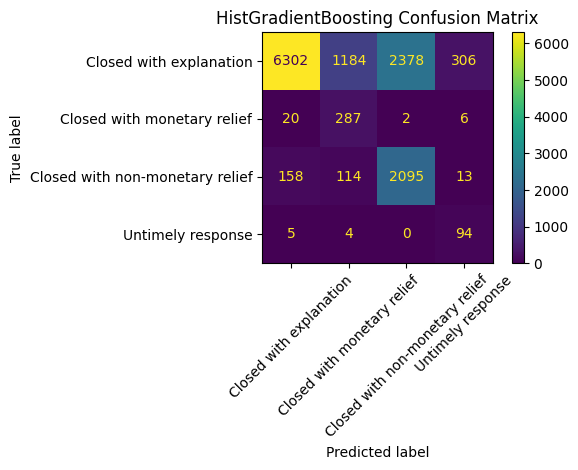

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test_model,
    gradient_boosting_predictions,
    xticks_rotation=45
)

plt.title("HistGradientBoosting Confusion Matrix")
plt.tight_layout()
plt.show()

### Key Finding — HistGradientBoosting

Best macro-F1 (0.507) and by far the best balanced accuracy (0.831) of the three models. Recall is strong and consistent across all minority classes (88-91%), unlike Random Forest's near-total miss on Monetary relief. The trade-off is lower precision on those same minority classes (18-47%) and lower recall on the majority class (62% vs Random Forest's 94%) — but that's the correct trade-off for this problem: missing a real monetary-relief case is worse than occasionally over-flagging one.

## 6. Overfitting Check

Comparing training vs. test macro-F1 for the leading model — a large gap would mean the model memorized training data rather than learning generalizable patterns.

In [34]:
gradient_boosting_train_predictions = gradient_boosting_model.predict(
    X_train_model
)

gradient_boosting_train_macro_f1 = f1_score(
    y_train_model,
    gradient_boosting_train_predictions,
    average="macro"
)

gradient_boosting_test_macro_f1 = f1_score(
    y_test_model,
    gradient_boosting_predictions,
    average="macro"
)

print(f"Training Macro F1: {gradient_boosting_train_macro_f1:.4f}")
print(f"Test Macro F1: {gradient_boosting_test_macro_f1:.4f}")

Training Macro F1: 0.5360
Test Macro F1: 0.5074


### Key Finding — Generalization

Training macro-F1 (0.536) vs. test macro-F1 (0.507) — a small gap of 0.029. The model is not meaningfully overfitting; performance on unseen data is close to what it achieves on the data it was trained on.

## 7. Model Comparison

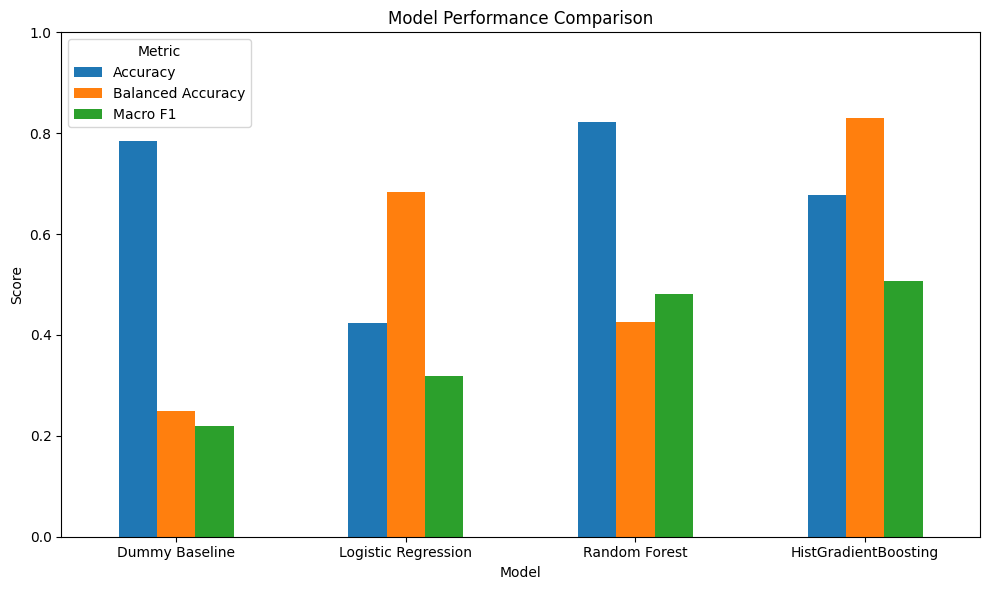

In [35]:
import matplotlib.pyplot as plt

metrics_to_plot = ["Accuracy", "Balanced Accuracy", "Macro F1"]
comparison_plot = model_results.set_index("Model")[metrics_to_plot]

comparison_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [36]:
model_results.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Balanced Accuracy,Macro F1
0,HistGradientBoosting,0.676897,0.830913,0.507407
1,Random Forest,0.822486,0.424931,0.480548
2,Logistic Regression,0.423581,0.683360,0.319384
3,Dummy Baseline,0.784238,0.250000,0.219768


### Key Finding — Why HistGradientBoosting Is the Final Model

Ranked by macro-F1: HistGradientBoosting (0.507) > Random Forest (0.481) > Logistic Regression (0.319) > Dummy Baseline (0.220). Random Forest's accuracy (0.822) is actually the highest of all four — but Section 4's finding already showed that number is misleading given its near-total failure on the Monetary relief class. HistGradientBoosting is selected because it's the only model that performs well **and** consistently across every class, not just the majority one.

## 8. Interpretability — Which Features Actually Drove Predictions

Permutation importance on the final model, measured against macro-F1 so the ranking reflects contribution to minority-class performance too, not just overall accuracy.

In [37]:
from sklearn.inspection import permutation_importance

importance_result = permutation_importance(
    gradient_boosting_model,
    X_test_model,
    y_test_model,
    n_repeats=5,
    random_state=42,
    scoring="f1_macro",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test_model.columns,
    "importance_mean": importance_result.importances_mean,
    "importance_std": importance_result.importances_std
}).sort_values("importance_mean", ascending=False).head(20)

display(importance_df)

,feature,importance_mean,importance_std
9,company_frequency,0.218273,0.006060
1,received_month,0.049619,0.002168
3,received_day,0.037013,0.002228
12,product_Credit reporting or other personal con...,0.009882,0.003865
7,narrative_length,0.003770,0.000726
0,received_year,0.003011,0.000298
22,sub_product_Checking account,0.002371,0.000579
45,sub_product_Other debt,0.001914,0.000337
6,narrative_present,0.001865,0.000942
13,product_Debt collection,0.001730,0.000777


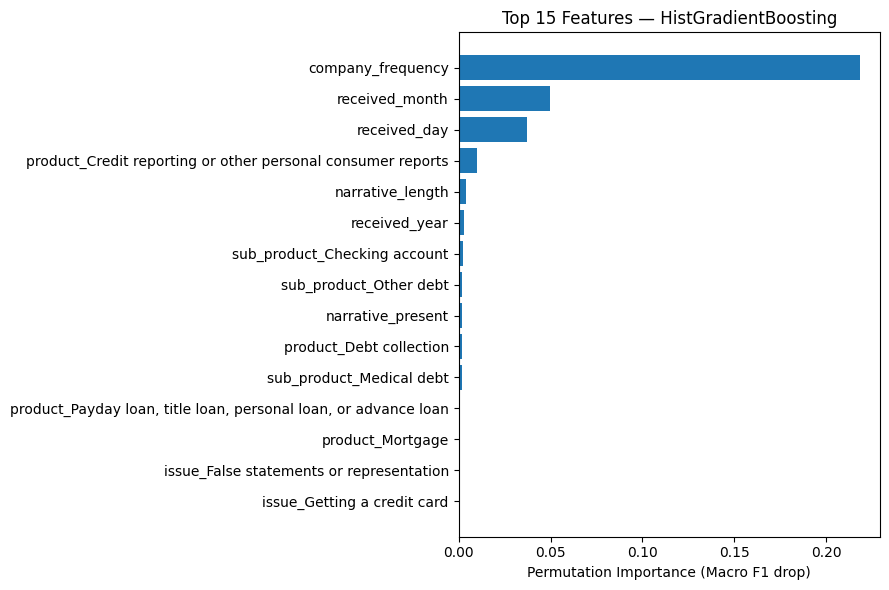

In [38]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(9, 6))
plt.barh(top_features["feature"], top_features["importance_mean"])
plt.xlabel("Permutation Importance (Macro F1 drop)")
plt.title("Top 15 Features — HistGradientBoosting")
plt.tight_layout()
plt.show()

### Key Finding — Feature Importance

company_frequency dominates by a wide margin (importance 0.218) — more than 4x the
next feature. This directly confirms the Feature Audit's finding that a small number
of large companies (Experian, TransUnion, Equifax) drive most of the volume and
behavior in this dataset.

Two features never validated in EDA turned out to matter more than expected:
received_month (0.050) and received_day (0.037) rank above nearly every individual
product/issue category. This is a genuinely new discovery from modeling, not
something carried over from earlier notebooks — worth a follow-up look at whether
company response patterns shift seasonally or by processing-day timing, since that
wasn't something EDA was scoped to check.

Individual product/issue one-hot columns (e.g. "Credit reporting..." at 0.0099,
"Debt collection" at 0.0017) rank much lower individually — expected, since one-hot
encoding spreads a category's signal thinly across many columns rather than
concentrating it in one, unlike company_frequency which is a single dense feature.

## 9. Save the Final Model

In [39]:
import joblib

MODEL_PATH = f"{PROCESSED_PATH}/hist_gradient_boosting_model.joblib"

joblib.dump(
    gradient_boosting_model,
    MODEL_PATH
)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: /content/drive/MyDrive/Consumer Complain Project/data/processed/hist_gradient_boosting_model.joblib


In [40]:
loaded_model = joblib.load(MODEL_PATH)

loaded_predictions = loaded_model.predict(X_test_model)

print("Model loaded successfully:", type(loaded_model).__name__)
print("Predictions match:", np.array_equal(
    gradient_boosting_predictions,
    loaded_predictions
))

Model loaded successfully: HistGradientBoostingClassifier
Predictions match: True


In [41]:
final_model_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "Training Macro F1",
        "Test Macro F1",
        "Train-Test Macro F1 Gap"
    ],
    "Score": [
        gradient_boosting_accuracy,
        gradient_boosting_balanced_accuracy,
        gradient_boosting_macro_f1,
        gradient_boosting_train_macro_f1,
        gradient_boosting_test_macro_f1,
        gradient_boosting_train_macro_f1 - gradient_boosting_test_macro_f1
    ]
})

final_model_summary

,Metric,Score
0,Accuracy,0.676897
1,Balanced Accuracy,0.830913
2,Macro F1,0.507407
3,Training Macro F1,0.536014
4,Test Macro F1,0.507407
5,Train-Test Macro F1 Gap,0.028608


In [42]:
RESULTS_PATH = f"{PROCESSED_PATH}/final_model_results.csv"

final_model_summary.to_csv(
    RESULTS_PATH,
    index=False
)

print(f"Final model results saved to: {RESULTS_PATH}")

Final model results saved to: /content/drive/MyDrive/Consumer Complain Project/data/processed/final_model_results.csv


In [43]:
saved_results = pd.read_csv(RESULTS_PATH)

print("Saved results loaded successfully.")
saved_results

Saved results loaded successfully.


,Metric,Score
0,Accuracy,0.676897
1,Balanced Accuracy,0.830913
2,Macro F1,0.507407
3,Training Macro F1,0.536014
4,Test Macro F1,0.507407
5,Train-Test Macro F1 Gap,0.028608


In [44]:
import os

processed_files = sorted(os.listdir(PROCESSED_PATH))

for file_name in processed_files:
    print(file_name)

X_test.parquet
X_train.parquet
complaints_cleaned.parquet
final_model_results.csv
hist_gradient_boosting_model.joblib
y_test.parquet
y_train.parquet


## Final Summary

**Model selected:** HistGradientBoosting — highest macro-F1 (0.507) and balanced accuracy (0.831) among all models tested, with a small train-test gap (0.029) indicating reasonable generalization rather than overfitting.

**Why not the higher-accuracy option:** Random Forest reached 82% accuracy, higher than HistGradientBoosting's 68% — but Section 4 showed that accuracy was hiding a near-total failure on the Monetary relief class (5% recall). Accuracy alone is the wrong metric for a dataset this imbalanced; macro-F1 and per-class recall tell the real story.

**How this model should actually be used:** as a triage and risk-flagging tool, not an automated decision-maker. Recall on minority classes is strong (88-91% for Monetary relief and Untimely response) — the model rarely misses a case genuinely worth reviewing. But precision on those same classes is low (18-47%), meaning a meaningful share of flagged complaints won't end up in that category. That trade-off is appropriate for prioritizing human review, not for skipping it.

**Known limitation carried from Feature Engineering:** 115 companies in the test set had zero training frequency, so predictions involving those companies rely entirely on non-company features and may be less reliable.

**Possible next steps, not required to consider this notebook complete:**
- Cross-validation for more robust minority-class metrics — the smallest class has only 103 test examples, so a single split gives a somewhat noisy estimate.
- Threshold or decision-rule tuning per class, since macro-F1 optimizes a single balance point that may not match the actual cost of a false positive vs. a false negative for each class.
- Repeat this same modeling process for `timely_response`, the project's primary target.